# Mutual Information

A partir de aqui estaremos viendo ingenieria de funciones (Feature Engineering). Feature Engieering tiene muchos usos utilies, uno de sus usos es el de crear nuevas funciones, o columnas, para poder utilizarlas despues y dar una mejor expliacion o solucion de lo que estamos viendo.

## Informacion Mutua
Cuando vemos un dataset con muchas columnas, nos podriamos imaginar si hay alguna relacion entre los valores que tenemos, ya que econtrar que relaciones son cruziales para el analisis de datos, tambien es parte de la tarea y nos puede ayudar mucho. La iformacion mutua generalmente lleva a algo que se le llama correlacion, que es informacion que surge cuando una funcion crece o decrese frente a otra que crece o decrese. Para entender esto veremos este caso.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("data/autos.csv")
df.head()

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


El dataset que estamos utilizando es el de Automobiles, de 1985. El motivo de este dataset es el de poder predecir el precio que tendra dependiendo de sus caracteristicas. Scikit-learn contiene una libreria para poder trabajar la parte de informacion mutua.

In [6]:
X = df.copy()
y = X.pop('price')

# hacemos una codificacion de las etiquetas objeto
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

discrete_features = X.dtypes == int

Usaremos la libreria de `mutial_info_regressor()` para las funciones discretas.

In [11]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features = discrete_features)
    mi_scores = pd.Series(mi_scores, name = 'MI Scores', index = X.columns)
    mi_scores = mi_scores.sort_values(ascending = False)
    return mi_scores

In [12]:
mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]

curb_weight          1.538410
highway_mpg          0.946614
length               0.614873
bore                 0.482862
stroke               0.393387
num_of_cylinders     0.332152
compression_ratio    0.133870
fuel_type            0.047279
Name: MI Scores, dtype: float64

Lo que hace mutual_info es comparar 2 columnas, una columna de X y y, para despues comparar otra columnas de X con y. Es decir, toma la informacion de las columans de X y las compara con el precio. Podemos hacer una grafica de comparacion para ver mejor esto.

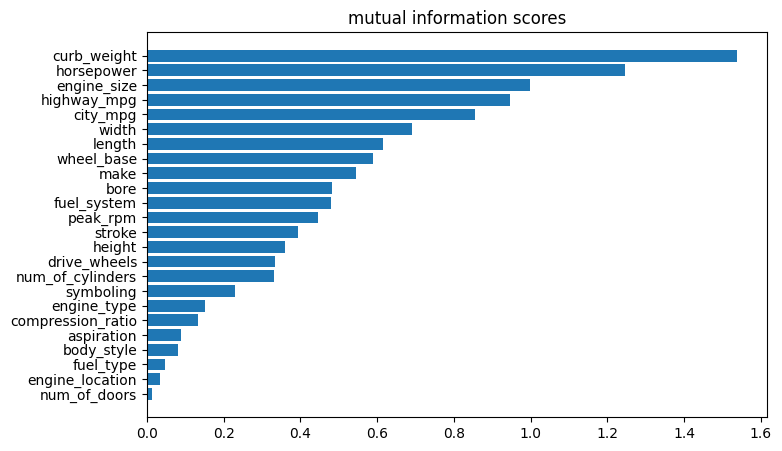

In [16]:
def plot_mi_score(scores):
    scores = scores.sort_values(ascending = True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("mutual information scores")

plt.figure(dpi = 100, figsize = (8, 5))
plot_mi_score(mi_scores)

Para ver mejor por que `curb-wight` y `horsepower` tienen esos lugares, entonces hagamos un mejor analizis con ellos.

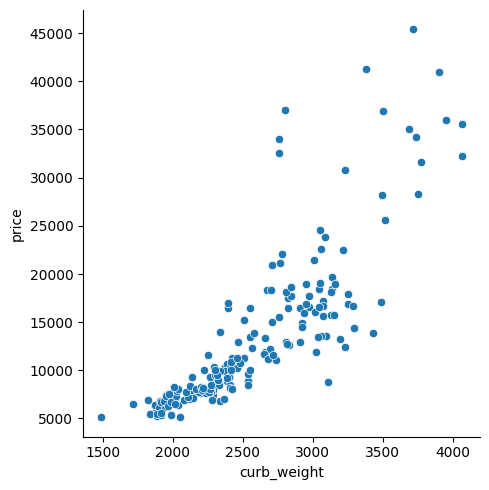

In [17]:
sns.relplot(x = 'curb_weight', y = 'price', data = df)

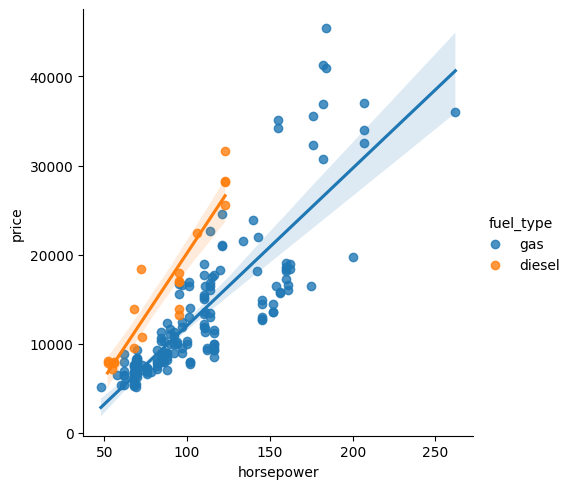

In [18]:
sns.lmplot(x = 'horsepower', y = 'price', hue = 'fuel_type', data = df)

Vemos dos cosas, conforme el precio del auto es mayo el peso tambien lo es, y que cuando el presio aumenta los caballos de fuerza tambien lo hace, pero esta segunda grafica tiene otro trasfondo. Vemos que en la grafica de barras `fuel_type` tiene poco que ver con el precio, es decir, el tipo de gasolina que consume no importa mucho respecto al precio, aunque si lo hace. Vemos en la grafica que el tipo de gasolina importa bastante en aquellos vehiculos que son de diesel y que los caballos de fuerza no son tantos pero igual su precio es elevado, es decir, hablamos de vahiculos pesados, aquellos que pesan mucho y que no tienen tanta potencia son los que usan diesel.

Utilizas estas comparaciones son utiles para saber que debemos tomar en cuenta, por ejemplo, type_fuel nos sirve para ver otra perspectiva hacerca de los vehiculos que anlizamos, pero estaria bien si no lo tomamos en cuenta cuando tratamos de hacer una prediccion, es decir, no iria dentro de los predicores que entrenarian un modelo.